     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00
Mounted at /content/drive
Label counts:
 label
0    154
1    159
Name: count, dtype: int64

Sensitive counts:
 sensitive
0    230
1     83
Name: count, dtype: int64

=== Group stats (seed first) ===
train | s=0 count=137  y=1 count=71  y=0 count=66
train | s=1 count=50  y=1 count=24  y=0 count=26
val | s=0 count=46  y=1 count=24  y=0 count=22
val | s=1 count=17  y=1 count=8  y=0 count=9
test | s=0 count=47  y=1 count=24  y=0 count=23
test | s=1 count=16  y=1 count=8  y=0 count=8
lambda=0.0 | seed 00 | acc=0.873 | ΔSP=0.053 | ΔEO=0.208 | best_epoch=3
lambda=0.0 | seed 01 | acc=0.762 | ΔSP=0.036 | ΔEO=0.083 | best_epoch=4
lambda=0.0 | seed 02 | acc=0.683 | ΔSP=0.263 | ΔEO=0.333 | best_epoch=16
lambda=0.0 | seed 03 | acc=0.698 | ΔSP=0.008 | ΔEO=0.083 | best_epoch=9
lambda=0.0 | seed 04 | acc=0.730 | ΔSP=0.158 | ΔEO=0.208 | best_epoch=

,seed,lambda_fair,best_epoch,test_acc,test_dsp,test_deo
0,0,0.0,3,0.873016,0.053191,0.208333
1,1,0.0,4,0.761905,0.035806,0.083333
2,2,0.0,16,0.682540,0.263298,0.333333
3,3,0.0,9,0.698413,0.007979,0.083333
4,4,0.0,27,0.730159,0.158245,0.208333
5,5,0.0,5,0.619048,0.109974,0.166667
6,6,0.0,5,0.777778,0.196809,0.000000
7,7,0.0,9,0.809524,0.144501,0.083333
8,8,0.0,6,0.714286,0.097187,0.041667
9,9,0.0,11,0.761905,0.115691,0.375000


,lambda_fair,acc_mean,acc_std,dsp_mean,dsp_std,deo_mean,deo_std
0,0.0,0.742857,0.070907,0.118268,0.076889,0.158333,0.123915
1,1.0,0.736508,0.049181,0.100458,0.080626,0.170833,0.135301



Saved: nba_contrastive_gcn_lambda01_all.csv
Saved: nba_contrastive_gcn_lambda01_summary.csv


,metric,mean_diff,CI95
0,ΔAcc (lambda1 - lambda0),-0.006349,"(-0.025396829843521117, 0.01111111044883728)"
1,ΔΔSP (lambda1 - lambda0),-0.017810,"(-0.062474749758839605, 0.017220164388418176)"
2,ΔΔEO (lambda1 - lambda0),0.012500,"(-0.037499988079071046, 0.07083334922790527)"


Saved: nba_contrastive_gcn_lambda01_paired.csv


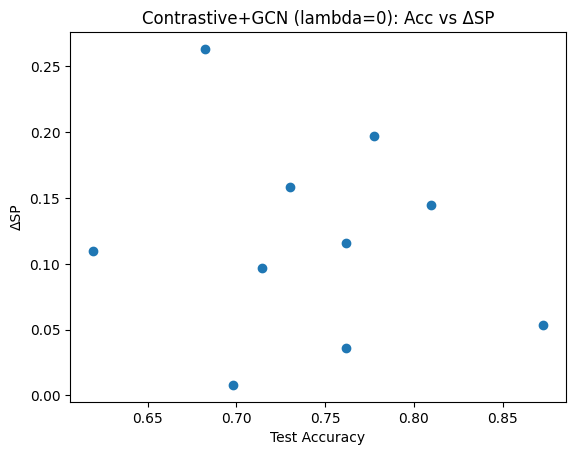

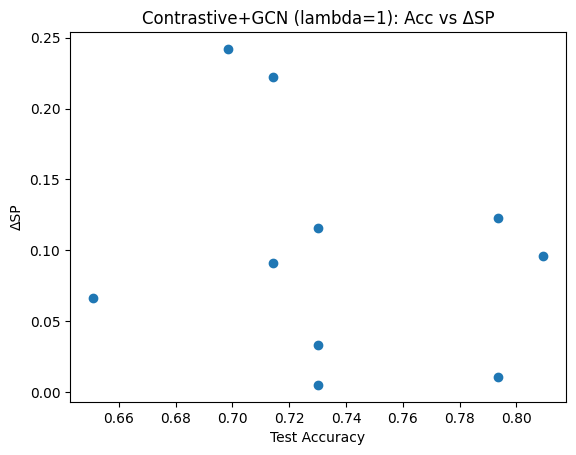

In [ ]:
# =========================
# 0) Install (Colab)
# =========================
%pip install -q torch torchvision torchaudio
%pip install -q torch-geometric
%pip install -q scikit-learn pandas numpy matplotlib

# =========================
# 1) Imports + utils
# =========================
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from google.colab import drive
drive.mount('/content/drive')

def set_global_seed(seed: int):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# =========================
# 2) Load & preprocess NBA dataset
# =========================
csv_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba.csv"
edge_path = "/content/drive/MyDrive/courses/network/NBA/dataset/nba_relationship.txt"

nodes = pd.read_csv(csv_path)

# Drop unknown labels
nodes["SALARY"] = pd.to_numeric(nodes["SALARY"], errors="coerce")
nodes = nodes[nodes["SALARY"].notna() & (nodes["SALARY"] != -1)].copy()

# Label (keep same as your baseline)
nodes["label"] = (nodes["SALARY"] > 0).astype(int)

# Sensitive attribute: country (binary)
country = pd.to_numeric(nodes["country"], errors="coerce").fillna(0)
nodes["sensitive"] = (country > 0).astype(int)

feature_cols = [
    c for c in nodes.columns
    if c not in ["user_id", "SALARY", "country", "label", "sensitive"]
]

print("Label counts:\n", nodes["label"].value_counts().sort_index())
print("\nSensitive counts:\n", nodes["sensitive"].value_counts().sort_index())

edges = pd.read_csv(edge_path, sep="\t", names=["src", "dst"])

# =========================
# 3) Stratified split masks (by (y, sensitive))
# =========================
def make_stratified_masks(y: torch.Tensor, s: torch.Tensor,
                          train_ratio=0.6, val_ratio=0.2, seed=0):
    y_np = y.cpu().numpy()
    s_np = s.cpu().numpy()
    strata = y_np * 2 + s_np  # 0..3

    idx_all = np.arange(len(y_np))

    # train vs temp
    sss1 = StratifiedShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    train_idx, temp_idx = next(sss1.split(idx_all, strata))

    # val vs test from temp
    temp_strata = strata[temp_idx]
    val_size_rel = val_ratio / (1 - train_ratio)

    sss2 = StratifiedShuffleSplit(n_splits=1, train_size=val_size_rel, random_state=seed)
    val_rel, test_rel = next(sss2.split(temp_idx, temp_strata))

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    n = len(y_np)
    train_mask = torch.zeros(n, dtype=torch.bool)
    val_mask = torch.zeros(n, dtype=torch.bool)
    test_mask = torch.zeros(n, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True
    return train_mask, val_mask, test_mask

def print_group_stats(y, s, mask, name):
    y_m = y[mask].cpu().numpy()
    s_m = s[mask].cpu().numpy()
    for sv in [0, 1]:
        idx = (s_m == sv)
        print(f"{name} | s={sv} count={idx.sum()}  y=1 count={(y_m[idx]==1).sum()}  y=0 count={(y_m[idx]==0).sum()}")

# =========================
# 4) Build PyG Data (train-only scaler, undirected graph)
# =========================
def build_data(nodes_df: pd.DataFrame, edges_df: pd.DataFrame,
               feature_cols, seed=0):
    y = torch.tensor(nodes_df["label"].values, dtype=torch.long)
    s = torch.tensor(nodes_df["sensitive"].values, dtype=torch.long)

    train_mask, val_mask, test_mask = make_stratified_masks(y, s, seed=seed)

    # Train-only scaler fit (avoid leakage)
    X_np = nodes_df[feature_cols].values
    scaler = StandardScaler()
    X_scaled = X_np.copy()

    train_idx = train_mask.numpy()
    X_scaled[train_idx] = scaler.fit_transform(X_np[train_idx])
    X_scaled[~train_idx] = scaler.transform(X_np[~train_idx])

    X = torch.tensor(X_scaled, dtype=torch.float)

    # Map user_id to 0..N-1
    id_map = {uid: i for i, uid in enumerate(nodes_df["user_id"].values)}

    src_list, dst_list = [], []
    for src, dst in zip(edges_df["src"], edges_df["dst"]):
        if src in id_map and dst in id_map:
            src_list.append(id_map[src])
            dst_list.append(id_map[dst])

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    # Make undirected
    edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

    data = Data(x=X, edge_index=edge_index, y=y)
    data.train_mask = train_mask
    data.val_mask = val_mask
    data.test_mask = test_mask
    data.sensitive = s
    return data

# =========================
# 5) Fairness metrics: ΔSP, ΔEO
# =========================
@torch.no_grad()
def fairness_metrics(y_true, y_pred, sensitive):
    def safe_mean(mask):
        return y_pred[mask].float().mean() if mask.any() else torch.tensor(float("nan"))

    p1_s0 = safe_mean(sensitive == 0)
    p1_s1 = safe_mean(sensitive == 1)

    tpr_s0 = safe_mean((sensitive == 0) & (y_true == 1))
    tpr_s1 = safe_mean((sensitive == 1) & (y_true == 1))

    delta_sp = torch.abs(p1_s0 - p1_s1)
    delta_eo = torch.abs(tpr_s0 - tpr_s1)
    return float(delta_sp), float(delta_eo)

# =========================
# 6) Augmentations for contrastive learning (GRACE-style)
# =========================
@torch.no_grad()
def random_edge_drop_undirected(edge_index: torch.Tensor, p: float, generator=None):
    """
    Drop undirected edges with probability p, then re-expand to directed.
    edge_index is assumed to already contain both directions.
    """
    if p <= 0.0:
        return edge_index

    device = edge_index.device
    u, v = edge_index[0], edge_index[1]

    # represent undirected edges by keeping u < v
    mask_upper = u < v
    undirected = edge_index[:, mask_upper]
    undirected = torch.unique(undirected, dim=1)

    E = undirected.size(1)
    keep = torch.rand(E, device=device, generator=generator) > p
    kept = undirected[:, keep]
    return torch.cat([kept, kept.flip(0)], dim=1)

@torch.no_grad()
def random_feature_drop(x: torch.Tensor, p: float, generator=None):
    if p <= 0.0:
        return x
    mask = torch.rand_like(x, generator=generator) > p
    return x * mask

def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, tau: float = 0.5):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits12 = (z1 @ z2.T) / tau
    logits21 = (z2 @ z1.T) / tau
    labels = torch.arange(z1.size(0), device=z1.device)
    return 0.5 * (F.cross_entropy(logits12, labels) + F.cross_entropy(logits21, labels))

def group_mean_alignment_loss(z: torch.Tensor, s: torch.Tensor):
    """
    Simple 'fair' regularizer during pretraining:
    || mean(z|s=0) - mean(z|s=1) ||^2
    """
    s0 = (s == 0)
    s1 = (s == 1)
    if s0.sum() == 0 or s1.sum() == 0:
        return torch.tensor(0.0, device=z.device)
    m0 = z[s0].mean(dim=0)
    m1 = z[s1].mean(dim=0)
    return torch.mean((m0 - m1) ** 2)

# =========================
# 7) Models: encoder, projector, supervised head
# =========================
class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class ProjectionHead(torch.nn.Module):
    def __init__(self, dim, proj_dim=64):
        super().__init__()
        self.fc1 = torch.nn.Linear(dim, dim)
        self.fc2 = torch.nn.Linear(dim, proj_dim)

    def forward(self, z):
        z = F.relu(self.fc1(z))
        return self.fc2(z)

class SupervisedGCN(torch.nn.Module):
    def __init__(self, encoder, hidden_dim=64, num_classes=2):
        super().__init__()
        self.encoder = encoder
        self.classifier = torch.nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        return self.classifier(z)

@torch.no_grad()
def evaluate_supervised(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    acc = (pred[mask] == data.y[mask]).float().mean().item()
    dsp, deo = fairness_metrics(data.y[mask], pred[mask], data.sensitive[mask])
    return acc, dsp, deo

# =========================
# 8) Train: contrastive pretrain -> supervised finetune
# =========================
def train_contrastive_then_gcn(
    data: Data,
    seed: int,
    lambda_fair: float,         # <--- this is what we'll compare (0 vs 1)
    pretrain_epochs: int = 200,
    tau: float = 0.5,
    p_edge: float = 0.2,
    p_feat: float = 0.2,
    proj_dim: int = 64,
    hidden_dim: int = 64,
    dropout: float = 0.5,
    lr_pretrain: float = 0.01,
    wd_pretrain: float = 5e-4,
    finetune_epochs: int = 500,
    patience: int = 50,
    lr_ft: float = 0.01,
    wd_ft: float = 5e-4,
):
    set_global_seed(seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)

    # (A) Pretrain
    encoder = GCNEncoder(data.num_features, hidden_channels=hidden_dim, dropout=dropout).to(device)
    projector = ProjectionHead(hidden_dim, proj_dim=proj_dim).to(device)

    opt_pre = torch.optim.Adam(
        list(encoder.parameters()) + list(projector.parameters()),
        lr=lr_pretrain,
        weight_decay=wd_pretrain
    )

    # Use train nodes for loss (conservative; avoids "using test labels" etc.)
    idx_train = data.train_mask.nonzero(as_tuple=False).view(-1)

    for epoch in range(1, pretrain_epochs + 1):
        encoder.train()
        projector.train()
        opt_pre.zero_grad()

        # deterministic augmentations given (seed, epoch)
        g1 = torch.Generator(device=device); g1.manual_seed(seed * 100000 + epoch * 2 + 0)
        g2 = torch.Generator(device=device); g2.manual_seed(seed * 100000 + epoch * 2 + 1)

        ei1 = random_edge_drop_undirected(data.edge_index, p_edge, generator=g1)
        ei2 = random_edge_drop_undirected(data.edge_index, p_edge, generator=g2)

        x1 = random_feature_drop(data.x, p_feat, generator=g1)
        x2 = random_feature_drop(data.x, p_feat, generator=g2)

        z1 = encoder(x1, ei1)
        z2 = encoder(x2, ei2)

        h1 = projector(z1)
        h2 = projector(z2)

        loss_cl = info_nce_loss(h1[idx_train], h2[idx_train], tau=tau)

        # fairness regularizer on encoder embeddings
        z_avg = 0.5 * (z1 + z2)
        loss_fair = group_mean_alignment_loss(z_avg[idx_train], data.sensitive[idx_train])

        loss = loss_cl + lambda_fair * loss_fair
        loss.backward()
        opt_pre.step()

    # (B) Finetune supervised with early stopping on val
    model = SupervisedGCN(encoder=encoder, hidden_dim=hidden_dim, num_classes=2).to(device)
    opt_ft = torch.optim.Adam(model.parameters(), lr=lr_ft, weight_decay=wd_ft)
    crit = torch.nn.CrossEntropyLoss()

    best_state = None
    best_val = -1.0
    best_epoch = 0
    bad = 0

    for epoch in range(1, finetune_epochs + 1):
        model.train()
        opt_ft.zero_grad()

        out = model(data.x, data.edge_index)
        loss = crit(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        opt_ft.step()

        val_acc, _, _ = evaluate_supervised(model, data, data.val_mask)
        if val_acc > best_val + 1e-4:
            best_val = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    model.load_state_dict(best_state)
    test_acc, test_dsp, test_deo = evaluate_supervised(model, data, data.test_mask)

    return {
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_dsp": test_dsp,
        "test_deo": test_deo,
    }

# =========================
# 9) Runner: one-click run for a given lambda_fair
# =========================
SEEDS = list(range(10))  # keep SAME as your other NBA notebooks

CFG_COMMON = dict(
    pretrain_epochs=200,
    tau=0.5,
    p_edge=0.2,
    p_feat=0.2,
    proj_dim=64,
    hidden_dim=64,
    dropout=0.5,
    finetune_epochs=500,
    patience=50,
)

def run_lambda(lambda_fair: float, seeds=SEEDS):
    rows = []
    for sd in seeds:
        data = build_data(nodes, edges, feature_cols, seed=sd)
        if sd == seeds[0]:
            print("\n=== Group stats (seed first) ===")
            print_group_stats(data.y, data.sensitive, data.train_mask, "train")
            print_group_stats(data.y, data.sensitive, data.val_mask, "val")
            print_group_stats(data.y, data.sensitive, data.test_mask, "test")

        out = train_contrastive_then_gcn(
            data=data,
            seed=sd,
            lambda_fair=lambda_fair,
            **CFG_COMMON
        )
        rows.append({"seed": sd, "lambda_fair": lambda_fair, **out})
        print(f"lambda={lambda_fair:.1f} | seed {sd:02d} | acc={out['test_acc']:.3f} | ΔSP={out['test_dsp']:.3f} | ΔEO={out['test_deo']:.3f} | best_epoch={out['best_epoch']}")
    df = pd.DataFrame(rows)
    return df

def summarize(df):
    summ = (df.groupby("lambda_fair")
              .agg(
                  acc_mean=("test_acc","mean"), acc_std=("test_acc","std"),
                  dsp_mean=("test_dsp","mean"), dsp_std=("test_dsp","std"),
                  deo_mean=("test_deo","mean"), deo_std=("test_deo","std"),
              )
              .reset_index())
    return summ

# =========================
# 10) One-click compare: lambda_fair = 0 vs 1 (same seeds)
# =========================
df_l0 = run_lambda(0.0, seeds=SEEDS)
df_l1 = run_lambda(1.0, seeds=SEEDS)

df_all = pd.concat([df_l0, df_l1], ignore_index=True)
display(df_all)

summary = summarize(df_all)
display(summary)

df_all.to_csv("nba_contrastive_gcn_lambda01_all.csv", index=False)
summary.to_csv("nba_contrastive_gcn_lambda01_summary.csv", index=False)
print("\nSaved: nba_contrastive_gcn_lambda01_all.csv")
print("Saved: nba_contrastive_gcn_lambda01_summary.csv")

# =========================
# 11) Paired effect (lambda=1 minus lambda=0) + bootstrap 95% CI
# =========================
def bootstrap_ci(diffs, B=20000, seed=0):
    diffs = np.asarray(diffs)
    rng = np.random.default_rng(seed)
    n = len(diffs)
    idx = rng.integers(0, n, size=(B, n))
    boot = diffs[idx].mean(axis=1)
    return float(np.quantile(boot, 0.025)), float(np.quantile(boot, 0.975))

base = df_l0.sort_values("seed").reset_index(drop=True)
cur  = df_l1.sort_values("seed").reset_index(drop=True)
assert (base["seed"].values == cur["seed"].values).all()

d_acc = cur["test_acc"].values - base["test_acc"].values
d_dsp = cur["test_dsp"].values - base["test_dsp"].values
d_deo = cur["test_deo"].values - base["test_deo"].values

paired = pd.DataFrame([{
    "metric": "ΔAcc (lambda1 - lambda0)",
    "mean_diff": float(d_acc.mean()),
    "CI95": bootstrap_ci(d_acc, seed=123),
},{
    "metric": "ΔΔSP (lambda1 - lambda0)",
    "mean_diff": float(d_dsp.mean()),
    "CI95": bootstrap_ci(d_dsp, seed=123),
},{
    "metric": "ΔΔEO (lambda1 - lambda0)",
    "mean_diff": float(d_deo.mean()),
    "CI95": bootstrap_ci(d_deo, seed=123),
}])

display(paired)

paired.to_csv("nba_contrastive_gcn_lambda01_paired.csv", index=False)
print("Saved: nba_contrastive_gcn_lambda01_paired.csv")

# =========================
# 12) Quick scatter plots (optional)
# =========================
plt.figure()
plt.scatter(df_l0["test_acc"], df_l0["test_dsp"])
plt.xlabel("Test Accuracy"); plt.ylabel("ΔSP")
plt.title("Contrastive+GCN (lambda=0): Acc vs ΔSP")
plt.show()

plt.figure()
plt.scatter(df_l1["test_acc"], df_l1["test_dsp"])
plt.xlabel("Test Accuracy"); plt.ylabel("ΔSP")
plt.title("Contrastive+GCN (lambda=1): Acc vs ΔSP")
plt.show()